In [77]:
import torch
import torch.nn as nn

In [78]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs/vae_reduction_mean1')

In [79]:
device = torch.device("cpu")
# for nvidia gpu ( cuda backend )
if (torch.cuda.is_available()):
    device = torch.device("cuda")
  # mps for apple M GPU ( metal backend )
elif (torch.backends.mps.is_available()):
    device = torch.device("mps")

print("Using device:", device)

Using device: mps


In [80]:

lr = 1e-3
batch_size = 256
epochs = 100

In [81]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

dataset_path = '../data'


mnist_transform = transforms.Compose([
    transforms.ToTensor(),
])

kwargs = {'num_workers': 1, 'pin_memory': True}

train_dataset = MNIST(
    dataset_path, transform=mnist_transform, train=True, download=True)
test_dataset = MNIST(dataset_path, transform=mnist_transform,
                     train=False, download=True)

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size, shuffle=True, **kwargs)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size, shuffle=False, **kwargs)

In [82]:
import sys
sys.path.append('../')

from model import VAE


model = VAE(
    encoder= nn.Sequential(
        nn.Linear(784, 512),
        nn.ReLU(),
        nn.Linear(512,256),
        nn.ReLU(),
    ),
    decoder= nn.Sequential(
        nn.Linear(128, 256),
        nn.ReLU(),
        nn.Linear(256, 512),
        nn.ReLU(),
        nn.Linear(512, 784),
        nn.Sigmoid()
    ),
    mean= nn.Linear(256, 128),
    var= nn.Linear(256, 128)
).to(device)

VAE model initialized


In [83]:
from torch.optim import Adam


def loss_function(x, x_hat, mean, log_var):
    # sum over pixels then div by the batch dim
    reproduction_loss = nn.functional.mse_loss(
        x_hat, x, reduction='none').sum(dim=1).mean()
    # sum over the dimensions of the latent space then div by the batch dim
    KLD = torch.mean(-0.5 * torch.sum(1 + log_var - mean **
                     2 - log_var.exp(), dim=1), dim=0)
    return reproduction_loss, KLD


optimizer = Adam(model.parameters(), lr=lr)

In [84]:
print("Start training VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    overall_rec = 0
    overall_kl = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        batch_size = x.size(0)
        x = x.view(batch_size, 784)
        x = x.to(device)
        optimizer.zero_grad()
        _, mean, log_var,_,x_hat = model(x)
        if batch_idx == 0:
            writer.add_images('input', x[0].view(
                1, 1, 28, 28), epoch+1)
            writer.add_images('reconstruction', x_hat[0].view(
                1, 1, 28, 28), epoch+1)
            
        loss_rec,loss_kld = loss_function(x, x_hat, mean, log_var)
        loss_kld = torch.mean(loss_kld)
        loss = loss_rec + loss_kld
        overall_rec += loss_rec.item()
        overall_kl += loss_kld.item()
        overall_loss += loss.item()

        loss.backward()
        optimizer.step()

    writer.add_scalar('Loss/total', overall_loss / len(train_loader), epoch+1)
    writer.add_scalar('Loss/rec', overall_rec / len(train_loader), epoch+1)
    writer.add_scalar('Loss/kl', overall_kl / len(train_loader), epoch+1)
    print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ",
          overall_loss / len(train_loader))

print("Finish!!")

Start training VAE...
	Epoch 1 complete! 	Average Loss:  0.07551217079162598
	Epoch 2 complete! 	Average Loss:  0.06766869698433166
	Epoch 3 complete! 	Average Loss:  0.06758490433084204
	Epoch 4 complete! 	Average Loss:  0.06753535854055527
	Epoch 5 complete! 	Average Loss:  0.0675236813248472
	Epoch 6 complete! 	Average Loss:  0.0674948900303942
	Epoch 7 complete! 	Average Loss:  0.06748537154907876
	Epoch 8 complete! 	Average Loss:  0.06746908486523527
	Epoch 9 complete! 	Average Loss:  0.06746712197014626
	Epoch 10 complete! 	Average Loss:  0.0674240379257405
	Epoch 11 complete! 	Average Loss:  0.06743670426150586
	Epoch 12 complete! 	Average Loss:  0.06740049523241977
	Epoch 13 complete! 	Average Loss:  0.06739732077781191
	Epoch 14 complete! 	Average Loss:  0.06738273079725023
	Epoch 15 complete! 	Average Loss:  0.06738236796982745
	Epoch 16 complete! 	Average Loss:  0.06737028433287397
	Epoch 17 complete! 	Average Loss:  0.06735306534361332
	Epoch 18 complete! 	Average Loss:  0.

In [85]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
        batch_size = x.size(0)
        x = x.view(batch_size, 784)
        x = x.to(device)

        _, _, _, _, x_hat = model(x)

        break

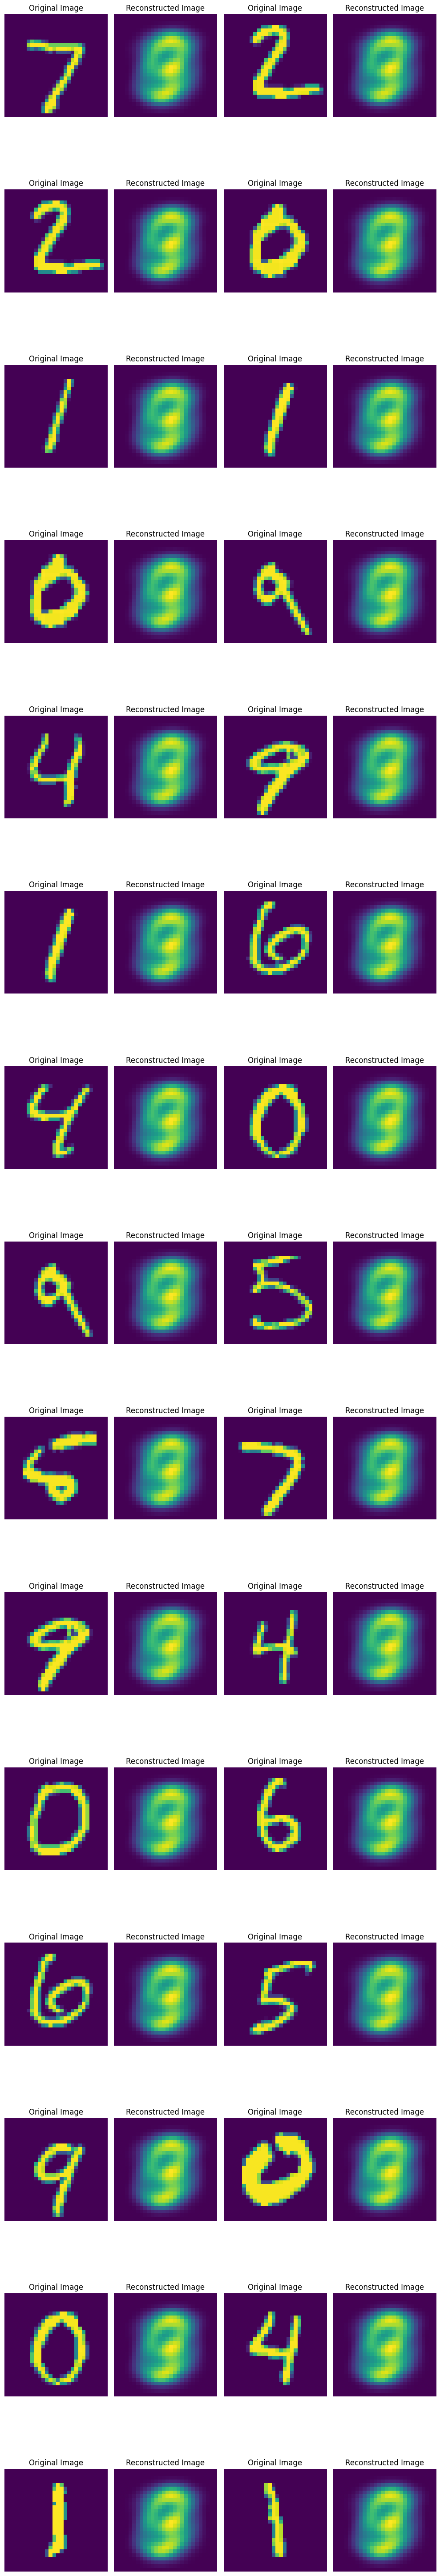

In [86]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=15, ncols=4, figsize=(10, 60))

for i in range(15):

    original_image = x[i].view(28, 28).cpu().numpy()
    reconstructed_image = x_hat[i].view(28, 28).cpu().numpy()

    axes[i, 0].imshow(original_image)
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(reconstructed_image)
    axes[i, 1].set_title('Reconstructed Image')
    axes[i, 1].axis('off')
    j = i*2+1
    original_image = x[j].view(28, 28).cpu().numpy()
    reconstructed_image = x_hat[j].view(28, 28).cpu().numpy()

    # Add your own images or modify as per your requirement
    axes[i, 2].imshow(original_image)
    axes[i, 2].set_title('Original Image')
    axes[i, 2].axis('off')

    axes[i, 3].imshow(reconstructed_image)
    axes[i, 3].set_title('Reconstructed Image')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()